# Analyse univariée et bivariée des données
## TP fil rouge : Parcoursup 2025

**Données** : formations proposées sur Parcoursup en 2025 (ministère de l'Enseignement supérieur, data.enseignementsup-recherche.gouv.fr).

**Organisation** : en binôme, un dépôt GitHub par binôme. Un commit à la fin de chaque partie.

Pour chaque question : du code, **et** une interprétation rédigée. Un chiffre sans phrase ne vaut rien.

---

### 🎯 La question de l'enquête

> **Qu'est-ce qui rend une formation sélective sur Parcoursup ?**

La sélectivité se mesure avec `taux_acces_ens` : la part des candidats qui ont reçu une proposition d'admission. Plus il est **bas**, plus la formation est **sélective**.

Chaque partie du TP fait avancer l'enquête. À la fin de chaque jour, vous rédigez une synthèse : *ce qu'on sait à ce stade sur la sélectivité*. La conclusion finale fait partie du TP noté.

# J1 matin — Comprendre les fondements de l'univarié

## Mise en place

Créez votre dépôt GitHub, clonez-le, placez `parcoursup.csv` dans un dossier `data/`.

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Chargez le fichier (séparateur : `;`). Combien de lignes et de colonnes ?

In [33]:
df = pd.read_csv(r"parcoursup.csv", sep=";")
df.head()

C:\Users\brume\AppData\Local\Temp\ipykernel_22940\1176617447.py:1: DtypeWarning: Columns (110) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"parcoursup.csv", sep=";")


,session,contrat_etab,cod_uai,g_ea_lib_vx,dep,dep_lib,region_etab_aff,acad_mies,ville_etab,lib_for_voe_ins,...,tri,cod_aff_form,detail_forma2,lien_form_psup,taux_acces_ens,part_acces_gen,part_acces_tec,part_acces_pro,etablissement_id_paysage,composante_id_paysage
0,2025,Public,0121471J,Institut national universitaire Champollion - ...,12,Aveyron,Occitanie,Toulouse,Rodez,Licence - Sciences et Techniques des Activités...,...,1_universités,2519,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,7.0,93,5,2,NaN,NaN
1,2025,Privé enseignement supérieur,0753605L,FAC LIBRE THEOLOGIE PROTESTANT,75,Paris,Ile-de-France,Paris,Paris 14e Arrondissement,Licence - Théologie - Parcours Théologie prote...,...,1_universités,25320,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,100.0,90,5,5,NaN,NaN
2,2025,Privé enseignement supérieur,0951809A,CY ILEPS,95,Val-d'oise,Ile-de-France,Versailles,Cergy,Licence - Sciences de l'éducation et de la for...,...,1_universités,25370,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,77.0,80,16,5,NaN,NaN
3,2025,Public,0922671D,I.U.T de Ville d'Avray - Antenne de Nanterre,92,Hauts-de-Seine,Ile-de-France,Versailles,Nanterre,BUT - Techniques de commercialisation,...,1_universités,25438,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,12.0,48,52,0,NaN,NaN
4,2025,Privé enseignement supérieur,0690195M,Institut Catholique de Lyon,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Lyon 2e Arrondissement,Licence - Double diplôme - Licence Droit - Dou...,...,1_universités,25443,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,60.0,100,0,0,NaN,NaN


## 1. Typologie des variables

🎯 *Enquête* : avant de chercher ce qui explique la sélectivité, il faut savoir quelles variables on a et comment les traiter.

Classez au moins ces colonnes : `fili`, `contrat_etab`, `select_form`, `cod_uai`, `capa_fin`, `voe_tot`, `taux_acces_ens`, `pct_bours`. Pour chacune : codage (ce que voit pandas), nature statistique, traitement retenu et justification.

| Variable         | Codage | Nature statistique | Traitement retenu | Justification                                                         |
| ---------------- | ------ | ------------------ | ----------------- | --------------------------------------------------------------------- |
| `fili`           | str    | qualitative        | nominale          | Catégorie de filière, sans ordre particulier.                         |
| `contrat_etab`   | str    | qualitative        | nominale          | Catégorie de contrat, sans ordre particulier.                         |
| `select_form`    | str    | qualitative        | nominale          | Type de sélection, sans ordre entre les modalités.                    |
| `cod_uai`        | str    | qualitative        | nominale          | Code permettant d’identifier un établissement, sans valeur numérique. |
| `capa_fin`       | int    | quantitative       | discrète          | Nombre de places disponibles, donc une valeur entière dénombrable.    |
| `voe_tot`        | int    | quantitative       | discrète          | Nombre total de vœux, donc une valeur entière dénombrable.            |
| `taux_acces_ens` | int    | quantitative       | continue          | Taux d’accès exprimé en pourcentage, représentant une proportion.     |
| `pct_bours`      | int    | quantitative       | continue          | Pourcentage de boursiers, représentant une proportion.                

## 2. Tendance centrale

🎯 *Enquête* : à quoi ressemble une formation « typique » ? Est-elle sélective ? On regarde d'abord la sélectivité, puis deux causes possibles : la demande (`voe_tot`) et la taille (`capa_fin`).

**2.1** Moyenne et médiane de `taux_acces_ens`. Que remarquez-vous ?

In [34]:
moyenne_taux = df["taux_acces_ens"].mean()
mediane_taux = df["taux_acces_ens"].median()

In [35]:
moyenne_taux, mediane_taux

(56.14736250614596, 54.0)

**Interprétation** : Le taux d’accès moyen est de 56,1 %, tandis que la médiane est de 54 %. La moyenne étant légèrement supérieure à la médiane, quelques formations avec un taux d’accès très élevé tirent la moyenne vers le haut. Une formation « typique » permet donc l’accès à environ la moitié des candidats, mais les situations restent variables.

**2.2** Moyenne et médiane de `voe_tot`. Une formation très demandée sera-t-elle forcément sélective ? Gardez la question en tête.

In [36]:
moyenne_voe = df["voe_tot"].mean()
mediane_voe = df["voe_tot"].median()

In [37]:
moyenne_voe, mediane_voe

(947.4028206567499, 385.0)

**Interprétation** : Le nombre moyen de vœux est de 947, contre une médiane de 385. La moyenne, beaucoup plus élevée, montre une forte asymétrie à droite : quelques formations très demandées tirent la moyenne vers le haut. Une formation typique reçoit donc environ 385 vœux. Mais Une forte demande ne signifie pas nécessairement qu’une formation est sélective.

**2.3** Quelle formation a la plus grande capacité (`capa_fin`) ? Que deviennent la moyenne et la médiane sans elle ?

In [38]:
formation_max = df.loc[df["capa_fin"].idxmax(), "lib_for_voe_ins"]
 
df_sans = df.drop(df["capa_fin"].idxmax())


In [39]:
print(f"Formation avec la plus grande capacité : {formation_max}")

Formation avec la plus grande capacité : BTS - Services - Diététique et nutrition - Entièrement en distanciel


In [40]:
print("Moyenne avant :", df["capa_fin"].mean())
print("Médiane avant :", df["capa_fin"].median())

Moyenne avant : 53.98196744316587
Médiane avant : 30.0


In [41]:
print("Moyenne sans le maximum :", df_sans["capa_fin"].mean())
print("Médiane sans le maximum :", df_sans["capa_fin"].median())

Moyenne sans le maximum : 53.747175636797415
Médiane sans le maximum : 30.0


**Interprétation** :  La formation ayant la plus grande capacité est **BTS - Services - Diététique et nutrition - Ent...**, avec **3 400 places**. Cette valeur extrême augmente légèrement la capacité moyenne, qui passe de **53,98 à 53,75 places** lorsqu’on la retire. En revanche, la médiane reste identique à **30 places** : elle est donc plus représentative d’une formation typique, car elle est peu influencée par cette valeur exceptionnelle.

**2.4** Mode de `fili` et de `contrat_etab`.

In [42]:
mode_fili = df["fili"].mode()
mode_contrat = df["contrat_etab"].mode()

In [43]:
print(mode_fili)
print(mode_contrat)

0    BTS
Name: fili, dtype: object
0    Public
Name: contrat_etab, dtype: object


**Interprétation** : La modalité la plus fréquente de `contrat_etab` est **Public**, avec **11 108 formations**, soit environ **77,9 %** du total. Pour `fili`, la catégorie dominante est **BTS**, avec **5 351 formations**, soit environ **37,5 %**. La répartition est donc fortement concentrée sur les établissements publics et, dans une moindre mesure, sur les BTS.

> 💾 **Commit** : « Tendance centrale »

## 3. Dispersion

🎯 *Enquête* : les formations sont-elles toutes à peu près aussi sélectives, ou y a-t-il de grands écarts à expliquer ?

On étudie la dispersion de `voe_tot` de bout en bout, puis on la compare à `taux_acces_ens`.

**3.1** Étendue de `voe_tot` (minimum, maximum, étendue).

In [44]:
voe_min = df['voe_tot'].min()
voe_max = df['voe_tot'].max()
etendu = voe_max - voe_min
print(voe_min)
print(voe_max)
print(etendu)

1
19404
19403


**Interprétation** : Le nombre de vœux varie de 1 à 19 404, soit une étendue de 19 403 vœux. Cela montre qu'il existe une forte différence de demande entre les formations : certaines reçoivent très peu de vœux tandis que d'autres en reçoivent plusieurs milliers. La demande est donc très variable d'une formation à l'autre.

**3.2** Variance pas à pas sur les **10 premières formations** : écarts à la moyenne, écarts au carré, somme des écarts. Calculez la variance en divisant par n, puis par n − 1. Vérifiez avec numpy et pandas.

In [45]:
echant = df["voe_tot"].sample(10, random_state=18).values

n = len(echant)

moy_echant = echant.mean()

ecarts = echant - moy_echant

ecart_2 = ecarts ** 2

somme_ecarts = ecarts.sum()
somme_ecarts_2 = ecart_2.sum()

variance_n = somme_ecarts_2 / n
variance_n_moins_1 = somme_ecarts_2 / (n - 1)

print("Moyenne :", moy_echant)
print("Somme des écarts :", somme_ecarts)
print("Somme des écarts au carré :", somme_ecarts_2)
print("Variance avec n :", variance_n)
print("Variance avec n-1 :", variance_n_moins_1)

Moyenne : 448.2
Somme des écarts : 0.0
Somme des écarts au carré : 1704825.5999999996
Variance avec n : 170482.55999999997
Variance avec n-1 : 189425.06666666662


**Interprétation** : Les écarts à la moyenne sont assez importants et varient selon les formations. Certaines valeurs sont très éloignées de la moyenne, comme 1980 avec un écart de 1133,4, tandis que d'autres sont beaucoup plus faibles, comme 50 avec un écart de -796,6. Cela montre que le nombre de vœux est assez variable dans cet échantillon.

**3.3** Calculez tous les indicateurs de dispersion de `voe_tot` : variance, écart-type, écart absolu moyen, Q1, Q3, IQR, coefficient de variation. Comparez l'écart-type, l'écart absolu moyen et l'IQR.

In [46]:
variance = df["voe_tot"].var()
ecart_type = df["voe_tot"].std()
ecart_absolu_moyen = (df["voe_tot"] - df["voe_tot"].mean()).abs().mean()

q1 = df["voe_tot"].quantile(0.25)
q3 = df["voe_tot"].quantile(0.75)
iqr = q3 - q1

coefficient_variation = ecart_type / df["voe_tot"].mean()

print("Variance :", variance)
print("Écart-type :", ecart_type)
print("Écart absolu moyen :", ecart_absolu_moyen)
print("Q1 :", q1)
print("Q3 :", q3)
print("IQR :", iqr)
print("Coefficient de variation :", coefficient_variation)

Variance : 2509634.08703997
Écart-type : 1584.182466460215
Écart absolu moyen : 929.8966075064855
Q1 : 160.0
Q3 : 1016.0
IQR : 856.0
Coefficient de variation : 1.6721318872177755


**Interprétation** : Les indicateurs montrent une forte dispersion du nombre de vœux entre les formations. L'écart-type est de 1584,18 et l'écart absolu moyen est de 929,90. L'IQR de 856 signifie que les 50 % de valeurs centrales sont réparties sur un intervalle de 856 vœux. Le coefficient de variation de 1,67 confirme que la dispersion est importante par rapport à la moyenne.

**3.4** Comparez la dispersion de `voe_tot` et de `taux_acces_ens` (écart-type, IQR, coefficient de variation). Laquelle est la plus dispersée ? Qu'est-ce que ça dit des écarts de sélectivité entre formations ?

In [47]:
print("voe_tot : ")
print("Écart-type :", df["voe_tot"].std())
print("IQR :", df["voe_tot"].quantile(0.75) - df["voe_tot"].quantile(0.25))
print("CV :", df["voe_tot"].std() / df["voe_tot"].mean())

print("taux_acces_ens : ")
print("Écart-type :", df["taux_acces_ens"].std())
print("IQR :", df["taux_acces_ens"].quantile(0.75) - df["taux_acces_ens"].quantile(0.25))
print("CV :", df["taux_acces_ens"].std() / df["taux_acces_ens"].mean())

voe_tot : 
Écart-type : 1584.182466460215
IQR : 856.0
CV : 1.6721318872177755
taux_acces_ens : 
Écart-type : 28.59067054760637
IQR : 48.0
CV : 0.5092077218137682


**Interprétation** : 

> 💾 **Commit** : « Dispersion »

## 4. Graphiques

🎯 *Enquête* : voir la sélectivité, et trouver un premier indice de ce qui la fait varier.

**4.1** Histogramme de `taux_acces_ens`. À quelle forme vous attendiez-vous ? Qu'obtenez-vous ?

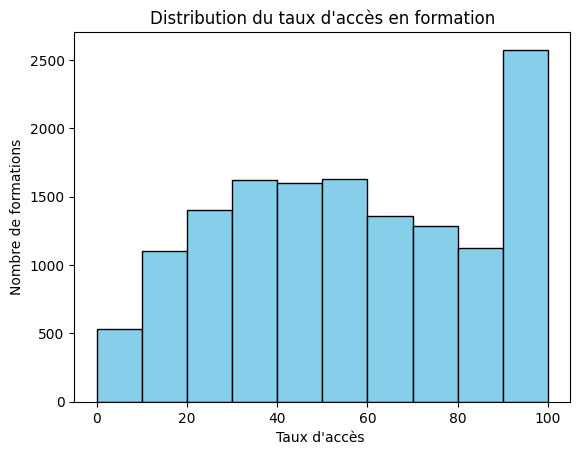

In [48]:
plt.hist(df['taux_acces_ens'], bins=10, color='skyblue', edgecolor='black')

plt.xlabel("Taux d'accès ")
plt.ylabel("Nombre de formations")
plt.title("Distribution du taux d'accès en formation")

plt.show()

**Interprétation** : Le taux d'accès est réparti sur différentes valeurs, avec une concentration plus importante de formations dans certaines zones. La distribution montre que les taux d'accès sont assez variables selon les formations.

**4.2** Diagramme en barres de `fili`, trié par effectif.

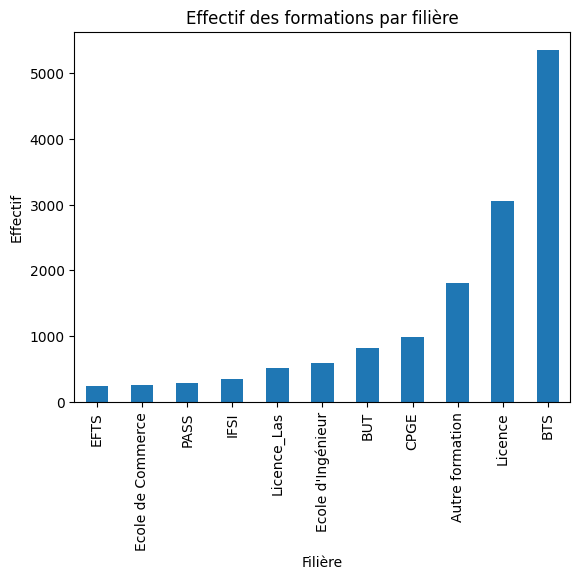

In [49]:
effectif = df["fili"].value_counts().sort_values()

effectif.plot(kind="bar")

plt.xlabel("Filière")
plt.ylabel("Effectif")
plt.title("Effectif des formations par filière")

plt.show()

**4.2 bis** Camembert de `contrat_etab`, puis camembert de `fili`. Lequel est lisible ? Pourquoi ?

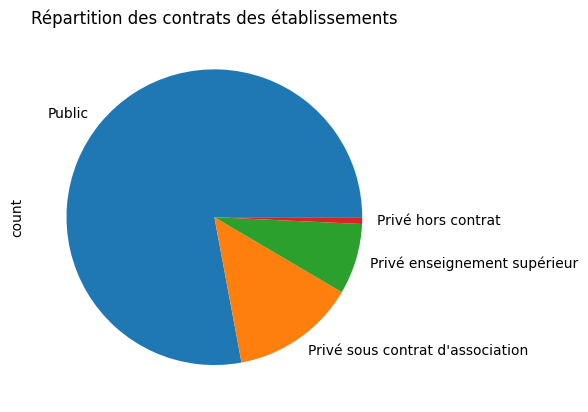

In [50]:
df["contrat_etab"].value_counts().plot(kind="pie")

plt.title("Répartition des contrats des établissements")
plt.show()

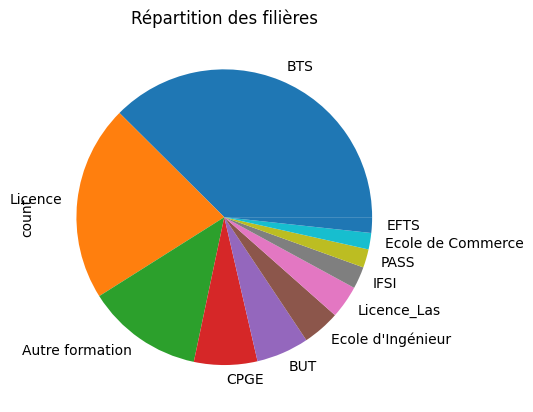

In [51]:
df["fili"].value_counts().plot(kind="pie")

plt.title("Répartition des filières")
plt.show()

**Interprétation** : Le camembert est lisible car contrat_etab comporte peu de modalités. On distingue facilement la part de chaque type d'établissement.
Le camembert est moins lisible car fili comporte beaucoup de modalités. Les parts sont nombreuses et parfois très petites. Un diagramme en barres est donc plus adapté.

**4.3** Boxplot de `voe_tot`. Est-il lisible ? Que faudrait-il faire ?

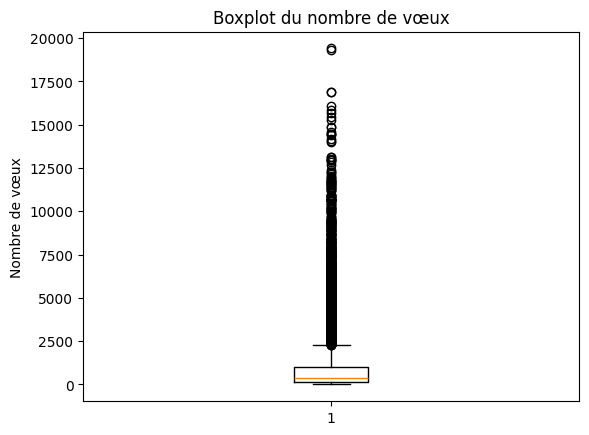

In [52]:
plt.boxplot(df["voe_tot"])

plt.ylabel("Nombre de vœux")
plt.title("Boxplot du nombre de vœux")

plt.show()

**Interprétation** : Le boxplot montre une dispersion du nombre de vœux avec plusieurs valeurs extrêmes. Ces valeurs élevées rendent la boîte difficile à lire. Une échelle logarithmique permettrait de mieux visualiser la distribution.

**4.4** Boxplots de `taux_acces_ens` selon `select_form`. Premier indice : le label « sélective » correspond-il vraiment à un taux d'accès plus faible ?

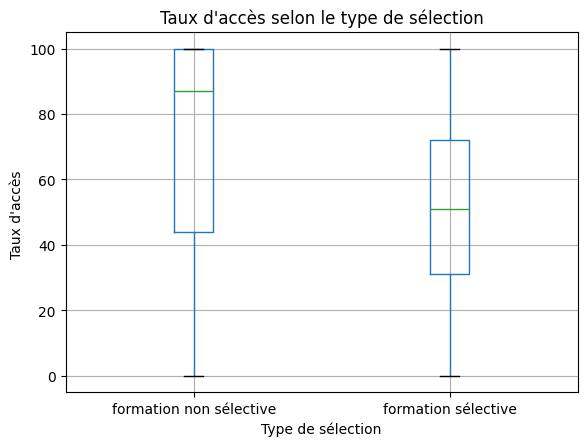

In [53]:
df.boxplot(column="taux_acces_ens", by="select_form")

plt.xlabel("Type de sélection")
plt.ylabel("Taux d'accès ")
plt.title("Taux d'accès selon le type de sélection")
plt.suptitle("")

plt.show()

**Interprétation** : Le boxplot montre que les formations sélectives ont globalement un taux d'accès plus faible que les formations non sélectives. Cela confirme que le caractère « sélective » correspond bien à un taux d'accès plus faible. On observe toutefois une dispersion des taux d'accès au sein des groupes.

> 💾 **Commit** : « Graphiques », puis **push**.

# J1 après-midi — Approfondir les distributions

In [54]:
from scipy import stats

## 5. Asymétrie et aplatissement

🎯 *Enquête* : la forme des variables décidera des outils à utiliser au J2 pour les relier à la sélectivité.

**5.1** Calculez la skewness et la kurtosis de `voe_tot`, `taux_acces_ens`, `capa_fin` et `pct_bours`. Classez-les de la plus symétrique à la plus asymétrique. Lesquelles faudra-t-il transformer avant de les relier à la sélectivité ?

In [55]:
colon = ["voe_tot", "taux_acces_ens", "capa_fin", "pct_bours"]

for co in colon:
    print(f" {co} : Skewness :", df[co].skew())
    print(f" {co} : Kurtosis :", df[co].kurt())
    print()

 voe_tot : Skewness : 4.078028972006451
 voe_tot : Kurtosis : 22.692827331847433

 taux_acces_ens : Skewness : 0.02666863440007404
 taux_acces_ens : Kurtosis : -1.136755663886813

 capa_fin : Skewness : 12.699780492922743
 capa_fin : Kurtosis : 282.0993436065393

 pct_bours : Skewness : 1.127791307172734
 pct_bours : Kurtosis : 1.918332105179366



**Interprétation** : Les résultats montrent des formes très différentes selon les variables. taux_acces_ens est la variable la plus symétrique avec une skewness proche de 0. pct_bours présente une asymétrie positive . voe_tot et surtout capa_fin sont fortement asymétriques à droite et présentent également une kurtosis élevée, indiquant la présence de valeurs extrêmes. 

> 💾 **Commit** : « Asymétrie »

## 6. La loi normale

🎯 *Enquête* : peut-on utiliser sur la sélectivité les outils qui supposent une loi normale ?

**6.1** Vérifiez la règle 68-95-99,7 sur `taux_acces_ens`. La variable suit-elle une loi normale ? Quelle conséquence pour la suite de l'enquête ?

In [62]:
moy = df["taux_acces_ens"].mean()
ecart = df["taux_acces_ens"].std()
 
print("68% :", ((df["taux_acces_ens"] >= moy - ecart) * (df["taux_acces_ens"] <= moy + ecart)).mean() * 100)
 
print("95% :", ((df["taux_acces_ens"] >= moy - 2 * ecart) * (df["taux_acces_ens"] <= moy + 2 * ecart )).mean() * 100)
 
print("99,7% :", ((df["taux_acces_ens"] >= moy - 3 * ecart) * (df["taux_acces_ens"] <= moy + 3 * ecart)).mean() * 100)

68% : 58.58125175413977
95% : 99.89475161380858
99,7% : 99.89475161380858


**Interprétation** :  Les proportions obtenues sont de 58,58 %, 99,89 % et 99,89 %. Elles s’éloignent de la règle 68-95-99,7, notamment pour le premier  écart-type. La distribution de taux_acces_ens n’est donc pas parfaitement normale.

> 💾 **Commit** : « Loi normale »

## 7. Les distributions réelles

🎯 *Enquête* : la demande (`voe_tot`) est une cause possible de sélectivité. Quelle échelle faudra-t-il utiliser pour la comparer au taux d'accès ?

**7.1** Tracez l'histogramme de `voe_tot`, puis celui de `log(voe_tot)`. Quelle loi reconnaissez-vous ? Quelle échelle utiliserez-vous au J2 pour relier la demande à la sélectivité ?

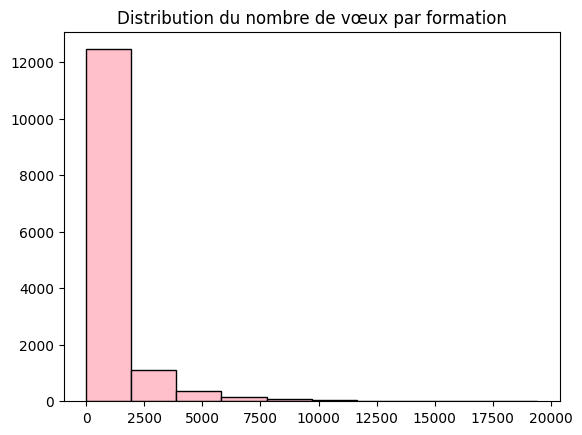

In [66]:
plt.hist(df["voe_tot"], bins=10, color='pink', edgecolor='black')
xlabel = "Nombre de vœux"
ylabel = "Nombre de formations"
plt.title("Distribution du nombre de vœux par formation")
plt.show()

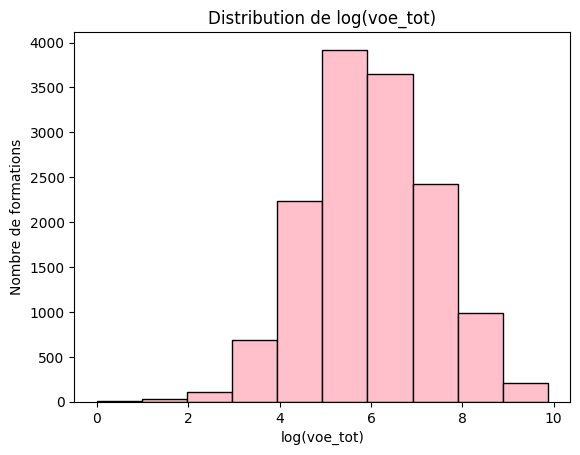

In [68]:
df["log_voe"] = np.log(df["voe_tot"])
plt.hist(df["log_voe"],  bins=10, color='pink', edgecolor='black')
plt.xlabel("log(voe_tot)")
plt.ylabel("Nombre de formations")
plt.title("Distribution de log(voe_tot)")
plt.show()

**Interprétation** : **Interprétation** : La distribution de `voe_tot` est très asymétrique : quelques formations concentrent beaucoup de vœux. Après transformation en `log(voe_tot)`, la distribution est plus équilibrée. 

**7.2** Quelle part des vœux concentrent les 10 % et les 20 % de formations les plus demandées ? Est-ce une distribution de type Pareto ?

In [69]:
voe = df["voe_tot"].sort_values(ascending=False)
 
total = df["voe_tot"].sum()
 
print("10 % :", voe.head(int(len(voe) * 0.10)).sum() / total * 100)
print("20 % :", voe.head(int(len(voe) * 0.20)).sum() / total * 100)

10 % : 49.81673237728002
20 % : 67.97622049734177


**Interprétation** : Les 10 % et 20 % des formations les plus demandées concentrent une part importante des vœux. La demande est donc très inégalement répartie, quelques formations attirent beaucoup de candidats. Cette répartition ressemble à une distribution de Pareto.

> 💾 **Commit** : « Distributions »

## 8. Outliers

🎯 *Enquête* : les formations hors norme risquent de fausser les liens avec la sélectivité. Faut-il les garder ?

**8.1** Détectez les outliers de `capa_fin` avec la méthode IQR, puis avec le Z-score (|z| > 3). Comparez les nombres obtenus et expliquez l'écart.

In [79]:
q1 = df["capa_fin"].quantile(0.25)
q3 = df["capa_fin"].quantile(0.75)
iqr = q3 - q1

borne_inf = q1 - 1.5 * iqr
borne_sup = q3 + 1.5 * iqr

trop_petits = df[df["capa_fin"] < borne_inf]
trop_grands = df[df["capa_fin"] > borne_sup]
nb_outliers_iqr = len(trop_petits) + len(trop_grands)

z = (df["capa_fin"] - df["capa_fin"].mean()) / df["capa_fin"].std()
outliers_z = df[z.abs() > 3]

print("Borne inférieure :", borne_inf)
print("Borne supérieure :", borne_sup)
print("Outliers IQR :", nb_outliers_iqr)
print("Outliers Z-score :", len(outliers_z))

Borne inférieure : -30.0
Borne supérieure : 98.0
Outliers IQR : 1689
Outliers Z-score : 183


**Interprétation** : Avec la méthode IQR, on obtient 1 689 outliers : toutes les formations de plus de 98 places sont considérées comme extrêmes. Avec le Z-score, on n'en obtient que 183 (plus de 353 places environ). L'écart s'explique par la forte asymétrie de capa_fin : les valeurs extrêmes gonflent l'écart-type, donc le Z-score devient moins sévère. La méthode IQR, basée sur les quartiles, est plus adaptée ici car elle n'est pas influencée par ces valeurs extrêmes.


**8.2** Affichez les 10 plus grandes capacités. S'agit-il d'erreurs ou de valeurs réelles ? Que faites-vous ? Les garderez-vous pour étudier la sélectivité ?

In [81]:
top10 = df.sort_values("capa_fin", ascending=False).head(10)

top10

,session,contrat_etab,cod_uai,g_ea_lib_vx,dep,dep_lib,region_etab_aff,acad_mies,ville_etab,lib_for_voe_ins,...,cod_aff_form,detail_forma2,lien_form_psup,taux_acces_ens,part_acces_gen,part_acces_tec,part_acces_pro,etablissement_id_paysage,composante_id_paysage,log_voe
10282,2025,Public,0381629P,CNED,38,Isère,Auvergne-Rhône-Alpes,Grenoble,Grenoble,BTS - Services - Diététique et nutrition - Ent...,...,20772,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,100.0,54,32,14,NaN,NaN,7.386471
9035,2025,Public,0690276A,CNED,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Lyon 4e Arrondissement,BTS - Services - Communication - Entièrement e...,...,20796,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,100.0,37,37,27,NaN,NaN,7.080868
7184,2025,Public,0690276A,CNED,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Lyon 4e Arrondissement,BTS - Services - Commerce International - Enti...,...,20794,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,100.0,40,38,22,NaN,NaN,7.507690
8389,2025,Public,0381629P,CNED,38,Isère,Auvergne-Rhône-Alpes,Grenoble,Grenoble,BTS - Services - Tourisme - Entièrement en dis...,...,20784,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,100.0,49,25,26,NaN,NaN,6.929517
8393,2025,Public,0690276A,CNED,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Lyon 4e Arrondissement,BTS - Services - Management Commercial Opérati...,...,20798,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,100.0,25,44,31,NaN,NaN,7.109879
7185,2025,Public,0690276A,CNED,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Lyon 4e Arrondissement,BTS - Services - Négociation et digitalisation...,...,20800,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,100.0,26,40,34,NaN,NaN,6.993015
5888,2025,Public,0381629P,CNED,38,Isère,Auvergne-Rhône-Alpes,Grenoble,Grenoble,BTS - Services - Economie sociale familiale - ...,...,20774,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,100.0,26,29,44,NaN,NaN,6.293419
9033,2025,Public,0381629P,CNED,38,Isère,Auvergne-Rhône-Alpes,Grenoble,Grenoble,BTS - Services - Services et prestations des s...,...,20778,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,100.0,18,40,42,NaN,NaN,6.408529
7186,2025,Public,0861273S,CNED,86,Vienne,Nouvelle Aquitaine,Poitiers,Chasseneuil-du-Poitou,BTS - Services - Services informatiques aux or...,...,20811,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,100.0,50,28,22,NaN,NaN,6.645091
5889,2025,Public,0861273S,CNED,86,Vienne,Nouvelle Aquitaine,Poitiers,Chasseneuil-du-Poitou,BTS - Services - Comptabilité et gestion - Ent...,...,20807,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,100.0,46,33,20,NaN,NaN,6.532334


**Interprétation** : Les 10 plus grandes capacités (de 1 500 à 3 400 places) sont presque toutes des BTS du CNED, plus une licence de droit, et toutes sont entièrement en distanciel. Ce ne sont donc pas des erreurs mais des valeurs réelles : une formation à distance n'a pas de limite de salles. Elles ont toutes un taux d'accès de 100 %. On les garde dans les données

> 💾 **Commit** : « Outliers », puis **push**.

## 9. Analyse univariée en autonomie

🎯 *Enquête* : deux nouveaux suspects. Le profil social des admis et la région peuvent-ils jouer sur la sélectivité ?

Vous disposez maintenant de toute la méthode. Analysez **seuls** les deux variables suivantes, en suivant les étapes ci-dessous :
- une variable **quantitative** : `pct_bours` (part de boursiers parmi les admis, en %) ;
- une variable **qualitative** : `region_etab_aff` (région de l'établissement).

| Étape | Variable quantitative | Variable qualitative |
|---|---|---|
| 1. Comprendre | Ce qu'elle mesure, son unité, discrète ou continue | Nominale ou ordinale, liste des modalités |
| 2. Qualité | Valeurs manquantes, 0 suspects, bornes | Valeurs manquantes, modalités mal orthographiées |
| 3. Centre | Moyenne et médiane, comparées | Mode (et médiane si ordinale) |
| 4. Dispersion | σ, IQR, CV | Nombre de modalités, part de la modalité dominante |
| 5. Visualiser | Histogramme, boxplot | Diagramme en barres |
| 6. Forme | Skewness, kurtosis, QQ-plot : quelle loi ? | Répartition équilibrée ou concentrée, modalités rares |
| 7. Extrêmes | IQR ou Z-score selon la forme, puis inspection | — |
| 8. Conclure | Quel résumé, quels outils pour la suite ? | Quel regroupement, quel encodage pour la suite ? |

> Chaque chiffre s'interprète en une phrase.

### Variable quantitative : `pct_bours`

**Analyse** : _à rédiger_

### Variable qualitative : `region_etab_aff`

**Analyse** : _à rédiger_

> 💾 **Commit** : « Analyse univariée », puis **push**.

## 📝 Synthèse J1 — Ce qu'on sait sur la sélectivité

- À quoi ressemble la sélectivité d'une formation typique ? Les formations sont-elles proches ou très différentes ?
- Quels premiers indices avez-vous trouvés sur ce qui la fait varier ?
- Quelles variables faudra-t-il transformer pour la suite, et pourquoi ?

4 à 6 lignes.

**Synthèse** : _à rédiger_

> 💾 **Commit** : « Synthèse J1 », puis **push**.

# J2 matin — Mettre en pratique les fondements mathématiques de la corrélation

## 10. Covariance

🎯 *Enquête* : on passe au bivarié. On apprend d'abord à mesurer un lien sur un couple simple (capacité × vœux), avant de l'appliquer à la sélectivité.

**10.1** Tracez le nuage de points de `voe_tot` en fonction de `capa_fin`. Calculez leur covariance à la main (produits des écarts), puis avec pandas.

**Interprétation** : _à rédiger_

**10.2** Recalculez la covariance avec la capacité exprimée en centaines de places. Que constatez-vous ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Covariance »

## 11. Corrélation de Pearson

🎯 *Enquête* : première mesure chiffrée du lien entre la demande et la sélectivité.

**11.1** Calculez r entre `capa_fin` et `voe_tot` à la main (covariance / produit des écarts-types), puis avec pandas. Faites de même pour `voe_tot` et `taux_acces_ens`. Que dit ce second coefficient sur la sélectivité ?

**Interprétation** : _à rédiger_

**11.2** Les conditions de Pearson sont-elles respectées ? Recalculez r entre `log(capa_fin)` et `log(voe_tot)` (en excluant les valeurs nulles).

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Pearson »

## 12. Corrélation de Spearman

🎯 *Enquête* : le lien demande × sélectivité est-il sous-estimé par Pearson ?

**12.1** Calculez Spearman pour les deux couples de la question 11.1. Comparez avec Pearson et expliquez les écarts.

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Spearman »

## 13. Tests d'hypothèse

🎯 *Enquête* : le lien entre demande et sélectivité est-il réel, ou dû au hasard ? Et quel coefficient retenir pour la suite ?

**13.1** Testez la normalité de `taux_acces_ens` avec Shapiro-Wilk et Anderson-Darling, sur un échantillon de 50 formations puis sur toutes. Formulez H0 et concluez. Quel coefficient de corrélation retiendrez-vous pour la suite de l'enquête ?

**Interprétation** : _à rédiger_

**13.2** Testez la corrélation entre `voe_tot` et `taux_acces_ens` (Spearman). Formulez H0, donnez la p-value et concluez. Le lien est-il fort pour autant ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Tests », puis **push**.

# J2 après-midi — Approfondir les relations quantitatives

## 14. Corrélation partielle

🎯 *Enquête* : le lien entre demande et sélectivité tient-il à capacité égale ?

**14.1** Calculez la corrélation entre `log(voe_tot)` et `taux_acces_ens`, puis la corrélation partielle en contrôlant `log(capa_fin)`. Que concluez-vous ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Corrélation partielle »

## 15. A/B testing

🎯 *Enquête* : un lien observé suffit-il à affirmer qu'un facteur *cause* la sélectivité ?

**15.1** Au J3, vous verrez que les formations privées ont un taux d'accès plus élevé que les publiques. Peut-on en conclure que le statut privé *rend* une formation moins sélective ? Quelle expérience faudrait-il pour le prouver, et est-elle possible ici ?

**Interprétation** : _à rédiger_

**15.2** Reprenez la simulation de la démo avec 500 visiteurs, puis 20 000. Une version B qui fait passer le taux d'achat de 20 % à 22 %. L'effet est-il détecté dans les deux cas ? Pourquoi ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « A/B testing »

## 16. Matrice de corrélation

🎯 *Enquête* : vue d'ensemble. Quelles variables quantitatives sont liées à la sélectivité, et lesquelles disent la même chose ?

**16.1** Tracez la heatmap des corrélations de Spearman entre `capa_fin`, `voe_tot`, `acc_tot`, `taux_acces_ens`, `pct_bours`, `pct_f`, `pct_tb`. Quelles variables sont redondantes ? Quelles variables sont les meilleures candidates pour expliquer la sélectivité ?

**Interprétation** : _à rédiger_

## 17. Régression simple

🎯 *Enquête* : le niveau scolaire des admis explique-t-il la sélectivité, et dans quelle mesure ?

**17.1** Régressez `taux_acces_ens` sur `pct_tb` (part de mentions très bien parmi les admis). Donnez la pente, le R², et tracez les résidus. Les mentions TB expliquent-elles la sélectivité ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Régression », puis **push**.

## 📝 Synthèse J2 — Ce qu'on sait sur la sélectivité

- Quelles variables quantitatives sont liées à la sélectivité, avec quelle force ?
- Le lien avec la demande tient-il quand on contrôle la taille ?
- Peut-on parler de causes ? Pourquoi ?

4 à 6 lignes.

**Synthèse** : _à rédiger_

> 💾 **Commit** : « Synthèse J2 », puis **push**.

# J3 matin — Comprendre les fondements du bivarié qualitatif

## 18. Table de contingence et Chi²

🎯 *Enquête* : le label « formation sélective » dépend-il du statut de l'établissement ?

**18.1** Croisez `select_form` et `contrat_etab` : table des effectifs, puis fréquences conditionnelles par statut.

**Interprétation** : _à rédiger_

**18.2** Faites le test du Chi² d'indépendance (H0, effectifs théoriques, p-value), puis calculez le V de Cramér et les résidus standardisés.

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Chi² »

## 19. Quantitatif × qualitatif

🎯 *Enquête* : la sélectivité varie-t-elle selon le statut (public / privé) et selon la filière ?

**19.1** Le `taux_acces_ens` diffère-t-il entre formations publiques et privées ? Boxplot, Student (Welch) et Mann-Whitney.

**Interprétation** : _à rédiger_

**19.2** Le `taux_acces_ens` diffère-t-il selon la filière (`fili`) ? ANOVA et Kruskal-Wallis. Quelles filières sont les plus sélectives ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Quanti × quali », puis **push**.

# J3 après-midi — Introduire le multivarié

## 20. ACP

🎯 *Enquête* : on rassemble toutes les variables. Où se place la sélectivité parmi elles ?

**20.1** Faites une ACP sur `log(capa_fin)`, `log(voe_tot)`, `taux_acces_ens`, `pct_bours`, `pct_f`, `pct_tb` (centrées-réduites). Quelle part de variance portent les deux premiers axes ? Interprétez-les à partir des contributions. Où se place `taux_acces_ens` sur ces axes ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « ACP », puis **push**.

## 🏁 Conclusion de l'enquête

Répondez à la question : **qu'est-ce qui rend une formation sélective sur Parcoursup ?**

- Les facteurs retenus, classés par importance, chacun appuyé par un chiffre du TP.
- Les pistes écartées.
- Les limites : ce que vos analyses ne permettent pas d'affirmer.

10 à 15 lignes. Cette conclusion compte dans la note du TP.

**Synthèse** : _à rédiger_

> 💾 **Commit** : « Conclusion de l'enquête », puis **push**.